# Synthetic Splice-Transducer Training

This notebook generates synthetic spliced coding examples on the fly and trains a small differentiable splice translator from the output amino-acid sequence. Nothing is saved to disk: every batch starts from random amino acids, reverse-translates them to DNA, splits the coding sequence across exons, inserts synthetic introns with donor/acceptor tracts, and then backpropagates through a soft splice-pointer/codon-buffer/frozen-codon-table path.

## What This Is Testing

The first version of this notebook fed the model a `transcript_rank` coordinate. That proved the differentiable pointer + codon-buffer + frozen-codon-table path could reach exact protein reconstruction, but it also handed the model a near-answer-key for transcript order.

This ablation removes that leak. The model now sees only DNA plus an `exon_prior` track by default. Donor, acceptor, and true transcript-rank annotations are still generated internally for inspection and future ablations, but they are not fed to the model in the default run.

The model below uses a Metal-friendly Mamba-style selective scan rather than free attention alone. The scan reads genomic positions in order and has to learn a latent transcript-coordinate state from the exon-prior stream. The pointer then aligns output transcript positions to those learned coordinate keys before the codon buffer and fixed codon table translate the result.

In [11]:
from __future__ import annotations

import math
import os
import random
import sys
from pathlib import Path

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from central_dogma_ai.biology import (
    AMINO_ACIDS,
    AA_TO_INDEX,
    CODONS_BY_AA,
    DNA_BASES,
    DNA_TO_INDEX,
)
from central_dogma_ai.torch_model import fixed_translate_codons

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

torch.manual_seed(1)
random.seed(1)
print(f'Using device: {device}')
device

Using device: mps


device(type='mps')

In [12]:
NONSTOP_AA = [aa for aa in AMINO_ACIDS if aa != '*']
MODEL_TRACK_NAMES = ('exon_prior',)
ANNOTATION_TRACK_NAMES = ('exon_prior', 'donor', 'acceptor', 'true_transcript_rank')


def random_dna(length: int, rng: random.Random) -> str:
    return ''.join(rng.choice(DNA_BASES) for _ in range(length))


def one_hot_dna(sequence: str) -> torch.Tensor:
    encoded = torch.zeros(len(sequence), 4)
    for index, base in enumerate(sequence):
        encoded[index, DNA_TO_INDEX[base]] = 1.0
    return encoded


def random_protein(codons: int, rng: random.Random, terminal_stop: bool = True) -> str:
    if terminal_stop:
        return ''.join(rng.choice(NONSTOP_AA) for _ in range(codons - 1)) + '*'
    return ''.join(rng.choice(NONSTOP_AA) for _ in range(codons))


def reverse_translate(protein: str, rng: random.Random) -> str:
    return ''.join(rng.choice(CODONS_BY_AA[amino_acid]) for amino_acid in protein)


def random_split_lengths(total_length: int, parts: int, rng: random.Random, min_part: int = 5) -> list[int]:
    if total_length < parts * min_part:
        raise ValueError('total_length is too short for the requested split')
    remaining = total_length
    lengths = []
    for part in range(parts - 1):
        max_length = remaining - min_part * (parts - part - 1)
        length = rng.randint(min_part, max_length)
        lengths.append(length)
        remaining -= length
    lengths.append(remaining)
    return lengths


def make_synthetic_example(
    protein_codons: int,
    exon_count: int,
    max_intron_length: int,
    rng: random.Random,
) -> dict[str, object]:
    protein = random_protein(protein_codons, rng)
    cds = reverse_translate(protein, rng)
    exon_lengths = random_split_lengths(len(cds), exon_count, rng)

    genome_parts = []
    exon_prior = []
    donor_track = []
    acceptor_track = []
    true_transcript_rank = []

    cds_cursor = 0
    transcript_cursor = 0
    for exon_index, exon_length in enumerate(exon_lengths):
        exon = cds[cds_cursor : cds_cursor + exon_length]
        cds_cursor += exon_length
        for base_index, base in enumerate(exon):
            genome_parts.append(base)
            exon_prior.append(1.0)
            donor_track.append(1.0 if exon_index < exon_count - 1 and base_index == exon_length - 1 else 0.0)
            acceptor_track.append(1.0 if exon_index > 0 and base_index == 0 else 0.0)
            true_transcript_rank.append(float(transcript_cursor))
            transcript_cursor += 1

        if exon_index < exon_count - 1:
            intron_length = rng.randint(8, max_intron_length)
            intron = 'GT' + random_dna(intron_length - 4, rng) + 'AG'
            for base in intron:
                genome_parts.append(base)
                exon_prior.append(0.0)
                donor_track.append(0.0)
                acceptor_track.append(0.0)
                true_transcript_rank.append(-1.0)

    genome = ''.join(genome_parts)
    target = torch.tensor([AA_TO_INDEX[amino_acid] for amino_acid in protein], dtype=torch.long)
    model_tracks = torch.tensor([[value] for value in exon_prior], dtype=torch.float32)
    annotations = torch.tensor(
        list(zip(exon_prior, donor_track, acceptor_track, true_transcript_rank)),
        dtype=torch.float32,
    )
    return {
        'genome': genome,
        'protein': protein,
        'dna': one_hot_dna(genome),
        'tracks': model_tracks,
        'annotations': annotations,
        'target': target,
    }


def make_batch(
    batch_size: int,
    protein_codons: int,
    exon_count: int = 3,
    max_intron_length: int = 36,
    seed: int | None = None,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, list[dict[str, object]]]:
    rng = random.Random(seed)
    examples = [
        make_synthetic_example(protein_codons, exon_count, max_intron_length, rng)
        for _ in range(batch_size)
    ]
    max_length = max(example['dna'].shape[0] for example in examples)

    dna_rows = []
    track_rows = []
    target_rows = []
    for example in examples:
        dna = example['dna']
        tracks = example['tracks']
        padding = max_length - dna.shape[0]
        dna_rows.append(torch.cat([dna, torch.zeros(padding, 4)], dim=0))
        track_rows.append(torch.cat([tracks, torch.zeros(padding, tracks.shape[1])], dim=0))
        target_rows.append(example['target'])

    return (
        torch.stack(dna_rows).to(device),
        torch.stack(track_rows).to(device),
        torch.stack(target_rows).to(device),
        examples,
    )

In [13]:
dna, tracks, target, examples = make_batch(batch_size=2, protein_codons=12, seed=4)
print(examples[0]['protein'])
print(examples[0]['genome'])
print('DNA tensor:', tuple(dna.shape))
print('model tracks:', tuple(tracks.shape), '=', MODEL_TRACK_NAMES)
print('annotation tracks:', tuple(examples[0]['annotations'].shape), '=', ANNOTATION_TRACK_NAMES)
print('target tensor:', tuple(target.shape))

ILEPSFDDAPV*
ATCTTAGAACCGTGGAGTCCCTGAGAAGATCATTTGATGTGCTTGTTCCGGAAAGGACGCCCCTGTATAG
DNA tensor: (2, 94, 4)
model tracks: (2, 94, 1) = ('exon_prior',)
annotation tracks: (70, 4) = ('exon_prior', 'donor', 'acceptor', 'true_transcript_rank')
target tensor: (2, 12)


In [ ]:
import subprocess


# --- Locate / import tommyip/mamba2-minimal ---------------------------------

def ensure_mamba2_minimal():
    """Import Mamba2/Mamba2Config from the local tommyip/mamba2-minimal checkout."""
    project_root = ROOT
    mamba_dir = project_root / "mamba2-minimal"

    if not mamba_dir.exists():
        print(f"Cloning mamba2-minimal into: {mamba_dir}")
        subprocess.run(
            ["git", "clone", "https://github.com/tommyip/mamba2-minimal.git", str(mamba_dir)],
            check=True,
        )

    sys.path.insert(0, str(mamba_dir))
    try:
        from mamba2 import Mamba2, Mamba2Config
    except ModuleNotFoundError as exc:
        if exc.name == 'einops':
            raise RuntimeError("mamba2-minimal needs einops. Install it in this env with: python -m pip install einops") from exc
        raise
    return Mamba2, Mamba2Config


Mamba2, Mamba2Config = ensure_mamba2_minimal()


class MinimalMamba2Block(nn.Module):
    """Residual wrapper around tommyip/mamba2-minimal Mamba2.

    The minimal implementation returns `(y, cache)` and requires sequence length
    to be a multiple of `chunk_size`; this wrapper handles both details.
    """

    def __init__(self, hidden_dim: int, chunk_size: int = 16):
        super().__init__()
        self.chunk_size = chunk_size
        self.norm = nn.LayerNorm(hidden_dim)
        config = Mamba2Config(
            d_model=hidden_dim,
            d_state=32,
            d_conv=4,
            expand=2,
            headdim=32,
            chunk_size=chunk_size,
        )
        self.mamba = Mamba2(config)
        self._reset_mamba_parameters()

    def _reset_mamba_parameters(self) -> None:
        with torch.no_grad():
            self.mamba.dt_bias.fill_(-2.0)
            self.mamba.A_log.zero_()
            self.mamba.D.fill_(1.0)

    def _pad_to_chunk(self, x: torch.Tensor) -> tuple[torch.Tensor, int]:
        remainder = x.shape[1] % self.chunk_size
        if remainder == 0:
            return x, 0
        pad_length = self.chunk_size - remainder
        padding = torch.zeros(x.shape[0], pad_length, x.shape[2], dtype=x.dtype, device=x.device)
        return torch.cat([x, padding], dim=1), pad_length

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        normalised = self.norm(x)
        padded, pad_length = self._pad_to_chunk(normalised)
        self.mamba.device = padded.device
        y, _cache = self.mamba(padded)
        if pad_length:
            y = y[:, :-pad_length]
        return residual + y


class MinimalMamba2Encoder(nn.Module):
    """Stack of Mamba2 blocks."""

    def __init__(self, hidden_dim: int, layers: int = 2, chunk_size: int = 16):
        super().__init__()
        self.layers = nn.ModuleList(
            [MinimalMamba2Block(hidden_dim, chunk_size=chunk_size) for _ in range(layers)]
        )
        self.final_norm = nn.LayerNorm(hidden_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x)
        return self.final_norm(x)


class MambaSplicePointerTranslator(nn.Module):
    def __init__(
        self,
        transcript_bases: int,
        input_dim: int = 5,
        hidden_dim: int = 32,
        layers: int = 3,
        chunk_size: int = 16,
    ):
        super().__init__()
        self.transcript_bases = transcript_bases
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        self.position_projection = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.scan_blocks = MinimalMamba2Encoder(
            hidden_dim=hidden_dim,
            layers=layers,
            chunk_size=chunk_size,
        )
        self.query = nn.Embedding(transcript_bases, hidden_dim)
        self.coordinate_head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )
        self.content_scale = nn.Parameter(torch.tensor(0.2))
        self.log_coordinate_sharpness = nn.Parameter(torch.tensor(-1.0))
        self.exon_prior_scale = nn.Parameter(torch.tensor(1.0))

    def forward(self, dna_one_hot: torch.Tensor, splice_tracks: torch.Tensor):
        batch_size, genome_length, _ = dna_one_hot.shape
        exon_prior = splice_tracks[..., 0:1]
        features = torch.cat([dna_one_hot, splice_tracks], dim=-1)

        genome_position = torch.linspace(0, 1, genome_length, device=dna_one_hot.device)
        genome_position = genome_position[None, :, None].expand(batch_size, -1, -1)
        encoded = (
            self.input_projection(features)
            + self.position_projection(torch.cat([genome_position, exon_prior], dim=-1))
        )
        encoded = self.scan_blocks(encoded)

        query = self.query.weight
        content_logits = torch.einsum("bld,td->btl", encoded, query) / math.sqrt(encoded.shape[-1])

        latent_coordinate = torch.sigmoid(self.coordinate_head(encoded).squeeze(-1))
        target_coordinate = torch.linspace(0, 1, self.transcript_bases, device=dna_one_hot.device)
        coordinate_sharpness = F.softplus(self.log_coordinate_sharpness)
        coordinate_bias = -coordinate_sharpness * (
            latent_coordinate[:, None, :] - target_coordinate[None, :, None]
        ).pow(2)
        exon_bias = self.exon_prior_scale.abs() * torch.log(
            exon_prior.squeeze(-1).clamp_min(1e-4)
        )[:, None, :]

        pointer_logits = self.content_scale * content_logits + coordinate_bias + exon_bias
        attention = pointer_logits.softmax(dim=-1)

        transcript_bases = torch.einsum("btl,blc->btc", attention, dna_one_hot)
        codon_bases = transcript_bases.reshape(batch_size, -1, 3, 4)
        amino_acid_probs = fixed_translate_codons(codon_bases).clamp_min(1e-8)

        attention_entropy = -(
            attention.clamp_min(1e-8) * attention.clamp_min(1e-8).log()
        ).sum(dim=-1).mean()
        mean_exon_attention = torch.einsum(
            "btl,bl->bt", attention, exon_prior.squeeze(-1)
        ).mean()
        coordinate_span = (
            latent_coordinate.max(dim=1).values - latent_coordinate.min(dim=1).values
        ).mean()

        return amino_acid_probs, attention, {
            "attention_entropy": attention_entropy.detach(),
            "coordinate_sharpness": coordinate_sharpness.detach(),
            "coordinate_span": coordinate_span.detach(),
            "exon_prior_scale": self.exon_prior_scale.detach().abs(),
            "mean_exon_attention": mean_exon_attention.detach(),
        }

## Train From Fresh Synthetic Batches

Each step generates a new batch. The model never sees stored examples. The only supervised target is the amino-acid sequence.

In [ ]:
protein_codons = 24
transcript_bases = protein_codons * 3
model = MambaSplicePointerTranslator(transcript_bases=transcript_bases).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)

history = []
steps = 250_000
batch_size = 64

for step in range(steps):
    dna, splice_tracks, target, _examples = make_batch(
        batch_size=batch_size,
        protein_codons=protein_codons,
        exon_count=3,
        max_intron_length=40,
        seed=10_000 + step,
    )
    amino_acid_probs, attention, diagnostics = model(dna, splice_tracks)
    aa_loss = F.nll_loss(torch.log(amino_acid_probs).reshape(-1, len(AMINO_ACIDS)), target.reshape(-1))

    optimizer.zero_grad(set_to_none=True)
    aa_loss.backward()
    optimizer.step()

    with torch.no_grad():
        predicted = amino_acid_probs.argmax(dim=-1)
        exact = (predicted == target).all(dim=1).float().mean().item()
        token_accuracy = (predicted == target).float().mean().item()
    history.append({
        'step': step,
        'loss': aa_loss.item(),
        'token_accuracy': token_accuracy,
        'exact_match': exact,
        'attention_entropy': diagnostics['attention_entropy'].item(),
        'coordinate_sharpness': diagnostics['coordinate_sharpness'].item(),
        'coordinate_span': diagnostics['coordinate_span'].item(),
        'mean_exon_attention': diagnostics['mean_exon_attention'].item(),
    })

    if step % 25 == 0 or step == steps - 1:
        print(
            f"step={step:03d} loss={aa_loss.item():.3f} "
            f"token_acc={token_accuracy:.3f} exact={exact:.3f} "
            f"entropy={diagnostics['attention_entropy'].item():.3f} "
            f"coord_span={diagnostics['coordinate_span'].item():.2f} "
            f"coord_sharp={diagnostics['coordinate_sharpness'].item():.3f} "
            f"exon_attention={diagnostics['mean_exon_attention'].item():.3f}"
        )

step=000 loss=3.133 token_acc=0.049 exact=0.000 entropy=4.270 coord_span=0.13 coord_sharp=0.313 exon_attention=1.000
step=025 loss=2.711 token_acc=0.176 exact=0.000 entropy=3.914 coord_span=1.00 coord_sharp=0.328 exon_attention=1.000
step=050 loss=2.489 token_acc=0.233 exact=0.000 entropy=3.471 coord_span=1.00 coord_sharp=0.349 exon_attention=1.000
step=075 loss=2.449 token_acc=0.247 exact=0.000 entropy=3.289 coord_span=1.00 coord_sharp=0.367 exon_attention=1.000
step=100 loss=2.455 token_acc=0.234 exact=0.000 entropy=3.181 coord_span=1.00 coord_sharp=0.382 exon_attention=1.000
step=125 loss=2.296 token_acc=0.283 exact=0.000 entropy=2.757 coord_span=1.00 coord_sharp=0.395 exon_attention=1.000
step=150 loss=2.238 token_acc=0.312 exact=0.000 entropy=2.583 coord_span=1.00 coord_sharp=0.404 exon_attention=1.000
step=175 loss=2.089 token_acc=0.323 exact=0.000 entropy=2.281 coord_span=1.00 coord_sharp=0.414 exon_attention=1.000


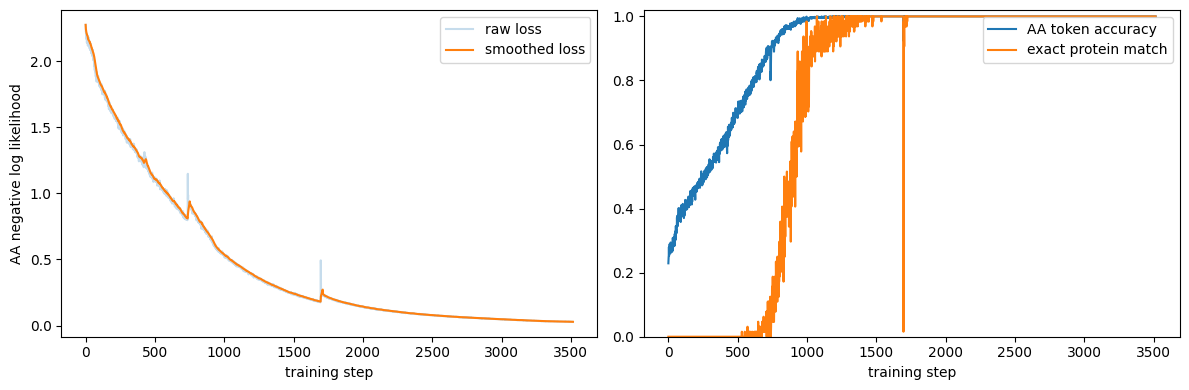

In [ ]:
steps_axis = [row['step'] for row in history]
losses = [row['loss'] for row in history]
token_accuracy = [row['token_accuracy'] for row in history]
exact_match = [row['exact_match'] for row in history]
attention_entropy = [row['attention_entropy'] for row in history]
mean_exon_attention = [row['mean_exon_attention'] for row in history]
coordinate_span = [row['coordinate_span'] for row in history]
coordinate_sharpness = [row['coordinate_sharpness'] for row in history]

window = 15
smooth_loss = [sum(losses[max(0, i - window + 1): i + 1]) / len(losses[max(0, i - window + 1): i + 1]) for i in range(len(losses))]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].plot(steps_axis, losses, alpha=0.25, label='raw loss')
axes[0].plot(steps_axis, smooth_loss, label='smoothed loss')
axes[0].set_xlabel('training step')
axes[0].set_ylabel('AA negative log likelihood')
axes[0].legend()

axes[1].plot(steps_axis, token_accuracy, label='AA token accuracy')
axes[1].plot(steps_axis, exact_match, label='exact protein match')
axes[1].set_xlabel('training step')
axes[1].set_ylim(0, 1.02)
axes[1].legend()

axes[2].plot(steps_axis, attention_entropy, label='attention entropy')
axes[2].plot(steps_axis, mean_exon_attention, label='mean exon attention')
axes[2].set_xlabel('training step')
axes[2].legend()

axes[3].plot(steps_axis, coordinate_span, label='latent coordinate span')
axes[3].plot(steps_axis, coordinate_sharpness, label='coordinate sharpness')
axes[3].set_xlabel('training step')
axes[3].legend()
plt.tight_layout()

target:     LAGADCKAEISGATFPNCGCRTR*
predicted:  LAGADCKAEISGATFPNCGCRTR*
genome length: 139
rank sharpness: 4.344361782073975


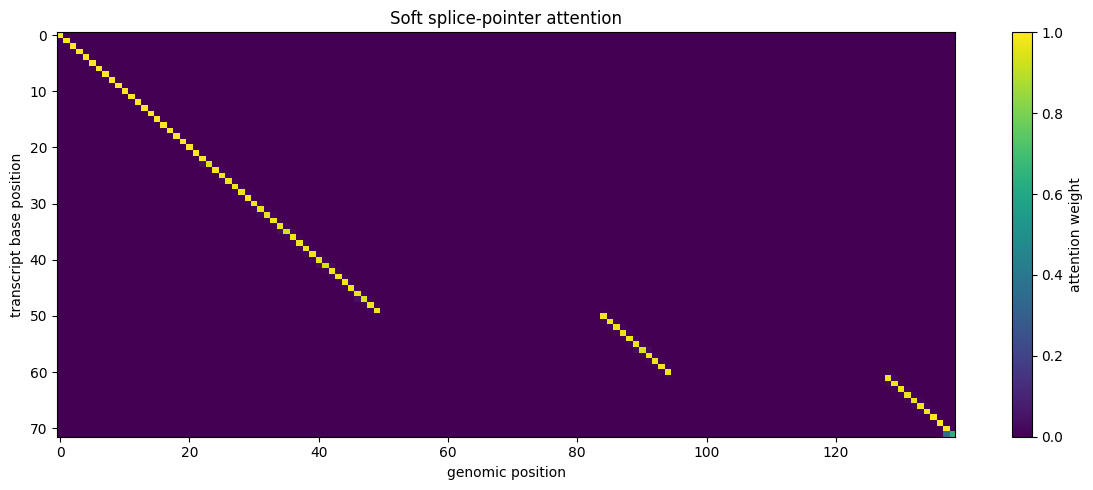

In [ ]:
dna, splice_tracks, target, examples = make_batch(batch_size=1, protein_codons=protein_codons, seed=123_456)
model.eval()
with torch.no_grad():
    amino_acid_probs, attention, diagnostics = model(dna, splice_tracks)
prediction = ''.join(AMINO_ACIDS[index] for index in amino_acid_probs.argmax(dim=-1)[0].tolist())
print('target:    ', examples[0]['protein'])
print('predicted: ', prediction)
print('genome length:', len(examples[0]['genome']))
print('attention entropy:', diagnostics['attention_entropy'].item())
print('coordinate span:', diagnostics['coordinate_span'].item())
print('coordinate sharpness:', diagnostics['coordinate_sharpness'].item())
print('mean exon attention:', diagnostics['mean_exon_attention'].item())

plt.figure(figsize=(12, 5))
plt.imshow(attention[0].detach().cpu().numpy(), aspect='auto', interpolation='nearest')
plt.xlabel('genomic position')
plt.ylabel('transcript base position')
plt.title('Mamba-style soft splice-pointer attention without transcript-rank input')
plt.colorbar(label='attention weight')
plt.tight_layout()